In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
import nltk
import string
from wordcloud import WordCloud
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import Sequential
from keras_preprocessing.sequence import pad_sequences
from keras_preprocessing.text import Tokenizer
from keras.layers import Dense, BatchNormalization, Embedding, LSTM, Dropout
from keras.metrics import Accuracy
from keras import utils
from keras import callbacks
from absl import logging

In [ ]:
pip install keras_preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = '/content/drive/MyDrive/Colab Notebooks/train.csv'
TEST_PATH  = '/content/drive/MyDrive/Colab Notebooks/test.csv'

# Data Loading and Exploration

Load and explore the structure of the dataset. Identify key characteristics such as the number of records, column types, and missing values.

In [ ]:
train_data = pd.read_csv(TRAIN_PATH)
test_data  = pd.read_csv(TEST_PATH)

In [ ]:
print('First 5 raws of train data')
display(train_data.head())

print('First 5 raws of test data')
display(test_data.head())

print('\nMain information about train data')
display(train_data.info())

print('\nMain information about test data')
display(test_data.info())

First 5 raws of train data


,review,sentiment
0,I caught this little gem totally by accident b...,positive
1,I can't believe that I let myself into this mo...,negative
2,*spoiler alert!* it just gets to me the nerve ...,negative
3,If there's one thing I've learnt from watching...,negative
4,"I remember when this was in theaters, reviews ...",negative


First 5 raws of test data


,review,sentiment
0,"Yes, MTV there really is a way to market Daria...",negative
1,The story of the bride fair is an amusing and ...,negative
2,"A team varied between Scully and Mulder, two o...",positive
3,This was a popular movie probably because of t...,negative
4,This movie made me so angry!! Here I am thinki...,negative



Main information about train data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     40000 non-null  object
 1   sentiment  40000 non-null  object
dtypes: object(2)
memory usage: 625.1+ KB


None


Main information about test data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


None

In [ ]:
# check missing values
print('Train data')
print(train_data.isna().sum())

print('\nTest data')
print(test_data.isna().sum())

Train data
review       0
sentiment    0
dtype: int64

Test data
review       0
sentiment    0
dtype: int64


**Summary:**
1. Train set contains 40,000 records with 2 main columns.
2. Test set contains 10,000 records with 2 main columns.
3. There are no missing values in both sets.

Next, we will proceed with preprocessing the text data by tokenizing and vectorizing it for model training.

## EDA (Exploratory Data Analysis)

In this section, we perform an analysis of the distribution of the sentiment labels and examine the length of the text data to gain insights into the dataset's characteristics. Understanding the distribution of classes and the length of the text is critical for designing appropriate preprocessing steps and selecting the right model.

**Sentiment Distribution Analysis**

In [ ]:
# Analyze the number of classes and label distribution in the 'sentiment' column
class_distribution = train_data['sentiment'].value_counts()

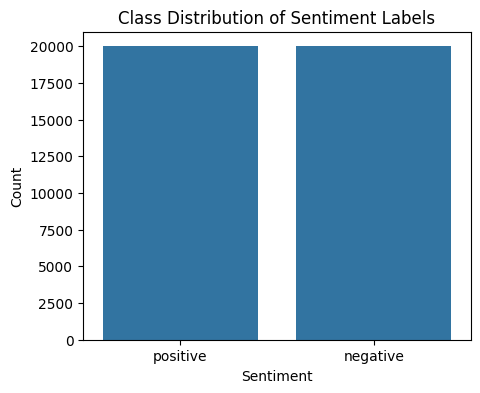

In [ ]:
# Plotting the sentiment distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='sentiment', data=train_data, order=class_distribution.index)
plt.title('Class Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

The plot shows that there are the same number of positive and negative labels.

**Distribution of Text Lengths**

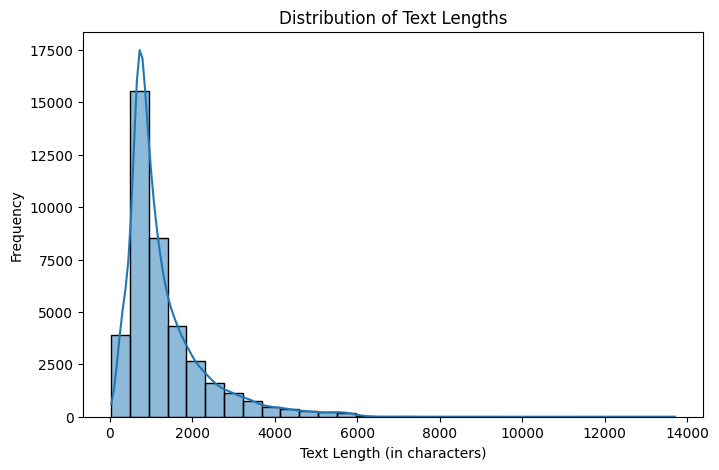

In [ ]:
# Plotting the distribution of text lengths
train_data['text_length'] = train_data['review'].apply(len)

plt.figure(figsize = (8, 5))
sns.histplot(train_data['text_length'], bins=30, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length (in characters)')
plt.ylabel('Frequency')
plt.show()

The histogram shows that most texts fall within the range of 700 to 1500 characters, with the average length being 1311 characters.

In [ ]:
# Displaying class distribution and summary of text length
class_distribution, train_data['text_length'].describe()

(sentiment
 positive    20000
 negative    20000
 Name: count, dtype: int64,
 count    40000.000000
 mean      1310.549450
 std        987.955229
 min         41.000000
 25%        699.000000
 50%        971.000000
 75%       1595.000000
 max      13704.000000
 Name: text_length, dtype: float64)

**Summary of Key Insights:**

1. Sentiment Class Distribution:
    - There are the same number of positive and negative labels.
2. Text Length Distribution:
    - The average length of texts is about 1311 characters.
    - The most common text lengths range between 700 and 1500 characters, with a drop off towards the end of the distribution.
    - The maximum length of texts in the data set is 13704 characters.

# Preprocessing Text Data and Vectorization Using Bag of Words

In this section, we focus on transforming raw text into numerical vectors using the Bag of Words method. To ensure meaningful and efficient representations of the text, we first perform several preprocessing steps, including:
- Removing stopwords: This eliminates common words that are not useful in the analysis.
- Tokenization: This breaks the text into individual words (tokens).
- Stemming: We use SnowballStemmer to reduce words to their base form, known as the word's stem.
- Word Vectorization: After preprocessing, we use CountVectorizer from sklearn to convert the preprocessed text into numerical vectors.

We download the required resources from nltk for tokenizing the text and removing stopwords (common words like "and," "the," etc.).

In [ ]:
# Download necessary resources for tokenization and stopwords
nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Create a stemmer for stemming words
stemmer = SnowballStemmer('english')

In [ ]:
# Define preprocessing function
def preprocess_text(text):
    """
    Preprocesses input text by applying a series of transformations to clean and standardize it.

    Steps involved in preprocessing:
    1. Converts text to lowercase to ensure uniformity.
    2. Tokenizes the text into individual words (tokens).
    3. Removes punctuation, non-alphanumeric characters, and stop words.
    4. Applies stemming to reduce words to their root form.
    5. Joins the tokens back into a single string.

    Parameters:
    text (str): The input text string to be preprocessed.

    Returns:
    str: A preprocessed, cleaned, and stemmed version of the input text.
    """
    text   = text.lower()
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word.isalnum() and word not in string.punctuation and word not in stop_words]

    return ' '.join(tokens)

In [ ]:
# Apply preprocessing method
train_data.loc[:, 'processed_review'] = train_data['review'].apply(preprocess_text)
test_data.loc[:, 'processed_review'] = test_data['review'].apply(preprocess_text)

**Visualizing Word Frequencies (Word Clouds)**

To better understand the most frequent words in the dataset after preprocessing, we generate Word Clouds to visualize word occurrences. This visualization helps identify the most important or frequent words in the text.

In [ ]:
# Generate and visualize word clouds
def visualize_wordcloud(text_data, title):
    """
    Generates and displays a word cloud visualization for a given text dataset.

    Parameters:
    - text_data (list of str): A list of strings (usually a collection of text) to visualize in the word cloud.
    - title (str): The title of the word cloud plot.
    """
    wordcloud = WordCloud(width = 800, height = 400, max_words = 100).generate(' '.join(text_data))
    plt.figure(figsize = (10, 5))
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

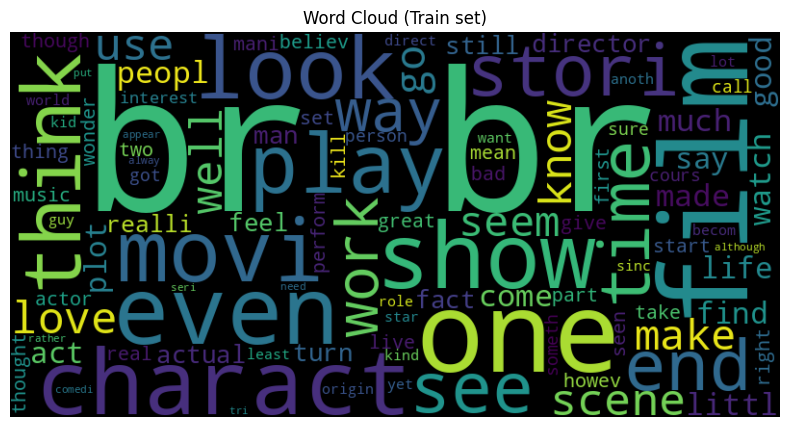

In [ ]:
visualize_wordcloud(train_data['processed_review'], "Word Cloud (Train set)")

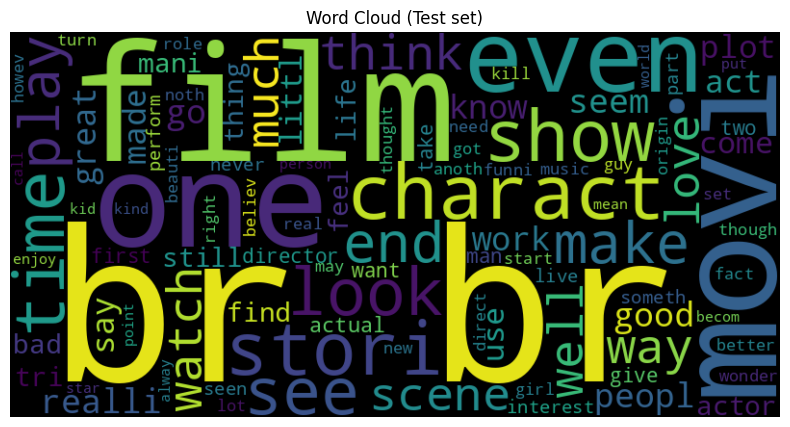

In [ ]:
visualize_wordcloud(test_data['processed_review'], "Word Cloud (Test set)")

These visualizations present the results from preprocessing, where punctuation was additionally removed, and all words were converted to lowercase. We can see that the key frequent words remain consistent, despite the cleaning steps. This indicates that the essential terms are preserved even after normalizing the text.

In [ ]:
# Get word frequency for Preprocess
words = ' '.join(train_data['processed_review']).split()
freq  = Counter(words).most_common(10)

print("Most common words in Preprocess:", freq)

Most common words in Preprocess: [('br', 161121), ('movi', 79969), ('film', 74516), ('one', 43024), ('like', 35189), ('time', 24077), ('good', 23384), ('make', 22838), ('charact', 22302), ('see', 22280)]


In [ ]:
# Count unique words for Preprocess
unique_words = len(set(words))

print(f"Unique words in Preprocess: {unique_words}")

Unique words in Preprocess: 61651


**Summary**

Preprocess method uses tokenization, stopword removal, and stemming, additionally removes punctuation and converts the text to lowercase.

# Building a Classifier

In this section, we will:
 - Data Preparation: Define X_train, y_train, X_test, y_test sets.

 - Classifier Training: Train a classifier (for example, Logistic Regression, Decision Tree, or one of the ensemble methods) on the vectorized data using the bag-of-words method. Experiment with different models and select the one with the highest accuracy.

 - Performance Evaluation: Provide information that allows us to assess the quality of the classification. This will involve analyzing performance metrics such as precision, recall, and F1-score.

 - Final Assessment: Evaluate the performance of the final classifier to determine its effectiveness in predicting sentiment labels accurately.

In [ ]:
# Vectorize the processed text using CountVectorizer (bag-of-words)
vectorizer = CountVectorizer(max_features = 1000)

X_train = vectorizer.fit_transform(train_data['processed_review'])
y_train = train_data['sentiment']
X_test  = vectorizer.fit_transform(test_data['processed_review'])
y_test  = test_data['sentiment']

In [ ]:
# Train and evaluate a classifier
def train_evaluate_classifier(classifier, X_train, X_test, y_train, y_test, classifier_name):
    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    print(f"\n{classifier_name} Performance:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    f1 = f1_score(y_test, y_pred, average = 'weighted')
    print(f"Weighted F1-score: {f1:.4f}")

In [ ]:
# Train and evaluate multiple classifiers

# Logistic Regression
train_evaluate_classifier(LogisticRegression(max_iter = 200), X_train, X_test, y_train, y_test, "Logistic Regression")

# Decision Tree
train_evaluate_classifier(DecisionTreeClassifier(), X_train, X_test, y_train, y_test, "Decision Tree")

# Random Forest
train_evaluate_classifier(RandomForestClassifier(), X_train, X_test, y_train, y_test, "Random Forest")

# Gradient Boosting
train_evaluate_classifier(GradientBoostingClassifier(), X_train, X_test, y_train, y_test, "Gradient Boosting")


Logistic Regression Performance:
              precision    recall  f1-score   support

    negative       0.54      0.72      0.62      5000
    positive       0.58      0.38      0.46      5000

    accuracy                           0.55     10000
   macro avg       0.56      0.55      0.54     10000
weighted avg       0.56      0.55      0.54     10000

Accuracy: 0.5507
Weighted F1-score: 0.5377

Decision Tree Performance:
              precision    recall  f1-score   support

    negative       0.54      0.58      0.56      5000
    positive       0.55      0.51      0.53      5000

    accuracy                           0.54     10000
   macro avg       0.55      0.54      0.54     10000
weighted avg       0.55      0.54      0.54     10000

Accuracy: 0.5449
Weighted F1-score: 0.5444

Random Forest Performance:
              precision    recall  f1-score   support

    negative       0.55      0.72      0.63      5000
    positive       0.60      0.41      0.49      5000

    ac

**Conclusions:**

1. Logistic Regression performs well with negative classes, achieving an F1-score of 0.62. However, its F1-score for positive classes is slightly lower at 0.46.
2. Decision Tree demonstrates the lowest performance metrics, with an F1-score across all classes ranging from approximately 0.53 to 0.56.
3. Random Forest performs well with negative classes, achieving an F1-score of 0.63, which is the highest among all models.
4. Gradient Boosting performs poorly with negative classes, achieving an F1-score of 0.59.

Overall, classification is challenging; however, there is room for improvement across all models.

# Creating and training a reccurent model (LSTM)

In [ ]:
train_data = pd.read_csv(TRAIN_PATH)
test_data  = pd.read_csv(TEST_PATH)

In [ ]:
review_train = train_data['review']
review_test  = test_data['review']

sentiment_train = train_data['sentiment']
sentiment_test  = test_data['sentiment']

In [ ]:
NUM_WORDS    = 10000
MAX_TEXT_LEN = 100

tokenizer = Tokenizer(num_words = NUM_WORDS)
tokenizer.fit_on_texts(review_train)
tokenizer.fit_on_texts(review_test)

In [ ]:
sequences_train = tokenizer.texts_to_sequences(review_train)
sequences_test  = tokenizer.texts_to_sequences(review_test)

index = 6
print(review_train[index])
print(sequences_train[index])

Heard about this film a long while ago and finally found it on ebay for five bucks. I wasn't expecting much but wow, was I ever surprised. It's a story of a boy and girl in love trying to escape an evil king who wants the girl for himself and takes place in a huge castle, reminds me of ICO for PS2 because some shots gave you a sense of vertigo.Sounds pretty standard but this movie is insane! It's hard to believe such an original animated feature was made in 1952. Also, the king was probably one of the creepiest character's I've seen in a long time, with a feminine walk, weird eyes (usually crossed), and a soft but scary voice. The only problem I had with the film was that the boy and girl had no personality and hardly even any lines except for calling for mr. wonderbird (A large talking green bird)to save them. The animation was fantastic in most areas but some cells were missing from some scenes which sucked. It's incredibly original with flying police and giant mechs and even laugh o

In [ ]:
X_train = pad_sequences(sequences_train, maxlen = MAX_TEXT_LEN)
y_train = sentiment_train.copy()

X_test = pad_sequences(sequences_test, maxlen = MAX_TEXT_LEN)
y_test = sentiment_test.copy()

In [ ]:
y_train.replace('positive', 1, inplace = True)
y_train.replace('negative', 0, inplace = True)
y_test.replace('positive', 1, inplace = True)
y_test.replace('negative', 0, inplace = True)

<ipython-input-18-2c520f1c0a67>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train.replace('negative', 0, inplace = True)
<ipython-input-18-2c520f1c0a67>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test.replace('negative', 0, inplace = True)


In [ ]:
#model = Sequential()
#model.add(Embedding(NUM_WORDS, 64, input_length=MAX_TEXT_LEN))
#model.add(LSTM(3, return_sequences = True))
#model.add(LSTM(5, return_sequences = True))
#model.add(BatchNormalization())
#model.add(LSTM(12))
#model.add(Dense(1, activation = 'sigmoid'))

model = Sequential()
# Увеличиваем размер Embedding слоя
model.add(Embedding(NUM_WORDS, 64, input_length=MAX_TEXT_LEN))

# Добавляем дополнительные LSTM слои и увеличиваем количество нейронов
model.add(LSTM(32, return_sequences=True))
model.add(Dropout(0.5))  # Dropout для регуляризации
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(128))

# Добавляем выходной слой
model.add(Dense(1, activation='sigmoid'))

In [ ]:
#callbacks = [
#    EarlyStopping(monitor = 'loss', min_delta = 0.01, patience = 10, verbose = 1),
#    ReduceLROnPlateau(monitor = 'loss', factor = 0.1, min_delta = 0.01, min_lr = 1e-10, patience = 4, verbose = 1, mode = 'auto')
#]

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

In [ ]:
model.compile(metrics = ['accuracy'], loss = 'binary_crossentropy', optimizer = 'Adam')

In [ ]:
history = model.fit(X_train, y_train, batch_size = 16, epochs = 20, validation_split = 0.2, callbacks = early_stopping)
history

Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.7681 - loss: 0.4693 - val_accuracy: 0.8609 - val_loss: 0.3523
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.8971 - loss: 0.2576 - val_accuracy: 0.8686 - val_loss: 0.3116
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9330 - loss: 0.1829 - val_accuracy: 0.8671 - val_loss: 0.3604
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9527 - loss: 0.1292 - val_accuracy: 0.8576 - val_loss: 0.3618
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9713 - loss: 0.0903 - val_accuracy: 0.8537 - val_loss: 0.4270
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9772 - loss: 0.0696 - val_accuracy: 0.8466 - val_loss: 0.5146
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9831 - loss: 0.0535 - val_accuracy: 0.8460 - val_loss: 0.6669


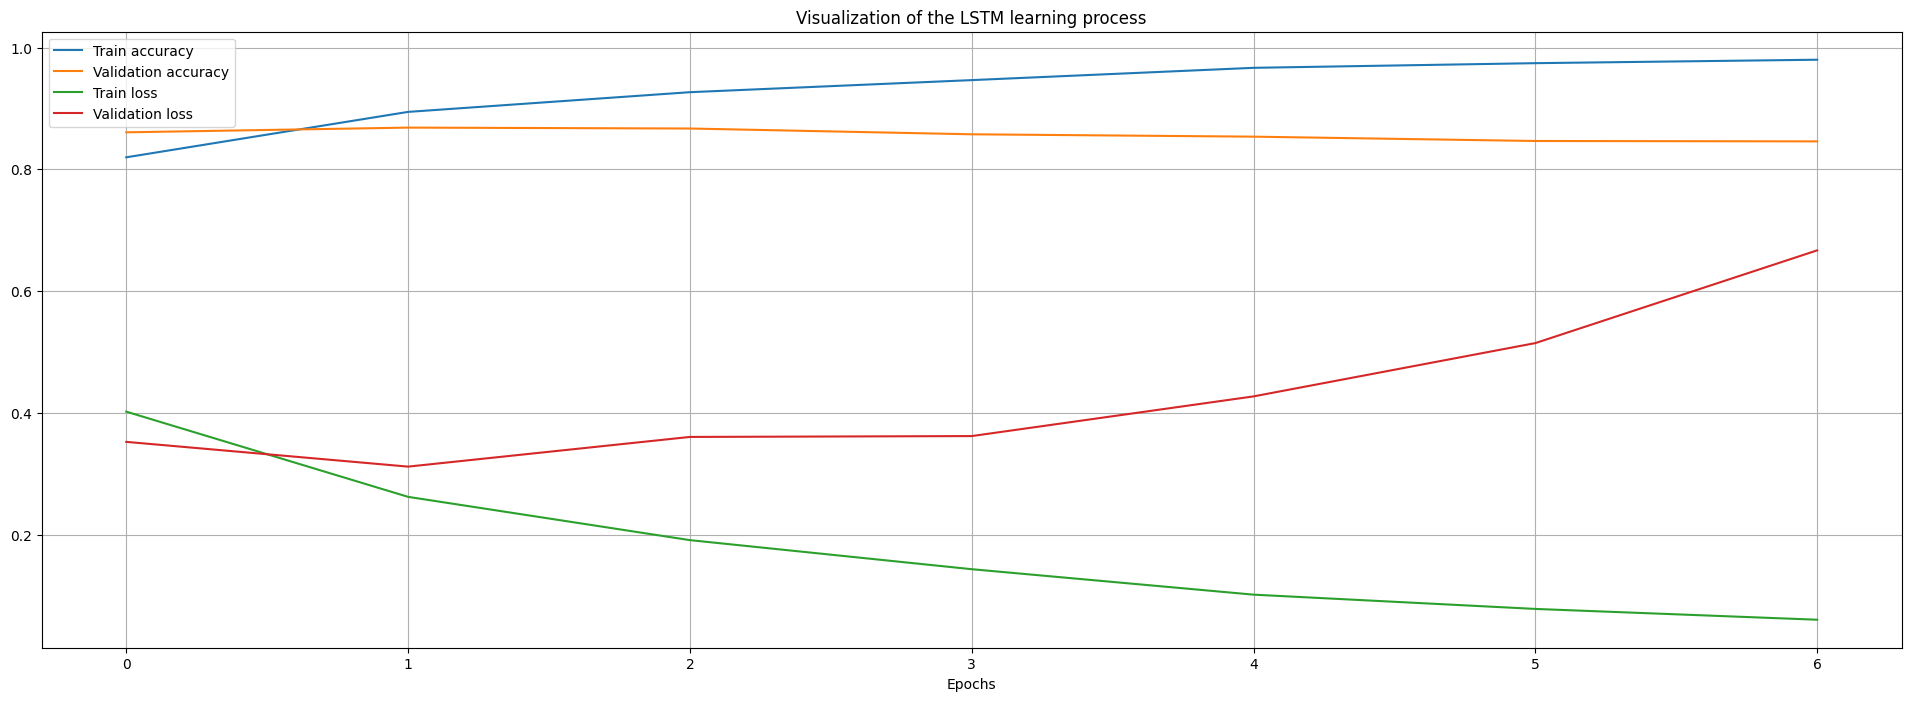

In [ ]:
plt.figure(figsize=(24, 8))
plt.title('Visualization of the LSTM learning process')
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')

plt.grid()
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8708 - loss: 0.3116


[0.3090209662914276, 0.8689000010490417]

In [ ]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.6 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

# Функция для создания модели
def build_model(hp):
    model = Sequential()
    # Подбор размерности Embedding
    embedding_dim = hp.Choice('embedding_dim', values=[32, 64, 128])
    model.add(Embedding(NUM_WORDS, embedding_dim, input_length=MAX_TEXT_LEN))

    # Подбор количества LSTM-слоев и нейронов в каждом
    for i in range(hp.Int('num_lstm_layers', 1, 3)):
        model.add(LSTM(units=hp.Int(f'lstm_units_{i}', min_value=32, max_value=128, step=32), return_sequences=True))
        model.add(Dropout(rate=hp.Float(f'dropout_rate_{i}', 0.2, 0.5, step=0.1)))

    model.add(LSTM(units=hp.Int('last_lstm_units', 32, 128, step=32)))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Инициализация Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',  # Можно поменять на 'val_loss' для минимизации ошибки
    max_trials=5,              # Количество комбинаций для исследования
    executions_per_trial=1,    # Количество запусков для каждой комбинации
    directory='my_dir',        # Папка для сохранения результатов
    project_name='lstm_tuning'
)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



In [ ]:
# Запуск поиска
tuner.search(X_train, y_train, epochs=10, validation_split=0.2)

Trial 5 Complete [00h 02m 36s]
val_accuracy: 0.8601250052452087

Best val_accuracy So Far: 0.8633750081062317
Total elapsed time: 00h 14m 50s


In [ ]:
# Получение лучших гиперпараметров
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best embedding_dim: {best_hps.get('embedding_dim')}")
print(f"Best number of LSTM layers: {best_hps.get('num_lstm_layers')}")

for i in range(best_hps.get('num_lstm_layers')):
    print(f"Best lstm_units for layer {i}: {best_hps.get(f'lstm_units_{i}')}")
    print(f"Best dropout_rate for layer {i}: {best_hps.get(f'dropout_rate_{i}')}")

print(f"Best last_lstm_units: {best_hps.get('last_lstm_units')}")

Best embedding_dim: 32
Best number of LSTM layers: 3
Best lstm_units for layer 0: 96
Best dropout_rate for layer 0: 0.30000000000000004
Best lstm_units for layer 1: 32
Best dropout_rate for layer 1: 0.2
Best lstm_units for layer 2: 32
Best dropout_rate for layer 2: 0.2
Best last_lstm_units: 96


In [ ]:
# Построение и обучение модели с лучшими гиперпараметрами
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=20, validation_split=0.2)
history

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.7321 - loss: 0.5079 - val_accuracy: 0.8601 - val_loss: 0.3247
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8886 - loss: 0.2765 - val_accuracy: 0.8684 - val_loss: 0.3144
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9203 - loss: 0.2070 - val_accuracy: 0.8673 - val_loss: 0.3511
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9459 - loss: 0.1518 - val_accuracy: 0.8524 - val_loss: 0.4260
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9578 - loss: 0.1185 - val_accuracy: 0.8601 - val_loss: 0.3661
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9773 - loss: 0.0769 - val_accuracy: 0.8487 - val_loss: 0.4781
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9788 - loss: 0.0648 - val_accuracy: 0.8474 - val_loss: 0.5573
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9851 -

In [ ]:
best_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8430 - loss: 0.8104


[0.794722855091095, 0.8454999923706055]